# Traffic-Sign Recognition System

## Problem description:

Self-driving cars, also called as autonomous cars are becoming popular and it seems to be one of the promising ways to reduce the road accident and other damages. Autonomous cars can drive without human intervention. These systems can take accurate and safe action/reactions only if it can recognize the road signs, buildings, pedestrians and other obstacles on the roadsides. Particularly, recognition of the traffic signal on the roadside is very important component while building the autonomous cars. The leading industries like Waymo, tesla, Argo AI in manufacturing the self-driven cars have adopted AI technology and deep learning technique for the traffic sign recognition. Since, there is nonverbal communication in self-driving cars, traffic sign recognition system plays an important role in such expert system. So, there is a need to develop traffic sign recognition system.

## Problem statement:

The problem is to develop a Traffic-sign recognition system which can recognize the traffic signs put up on the road e.g. "speed limit" or "children" or "turn ahead" etc. Given the traffic signs in the image form as input, the problem is to recognize the signs using Machine learning techniques. To solve the problem following are provided:

   - A huge collection of traffic signal taken under different scene is available as input. These signs may be not clearly visible, are challenging to process as they are taken from far
   - Separate set of images are for testing the model is available
   - Use the available data and develop a traffic sign recognition system which can categorize signs i.e, classify to which class the traffic sign belongs to.

## Project implementation:

Let first understand what traffic sign recognition is. Traffic signs are of different types like speed limits, traffic signal, turn left or right etc. Traffics recognition problem can be considered as traffic sign classification problem. Since, the traffic signs might have been captured from far, the model that we build should be able to detect accurately.

We use deep learning technique which can extract the features accurately and predict the sign class. The sign detection methods are based on the features like color, shape. To extract the features from the complex images, a deep learning technique - Convolutional Neural network and image processing techniques are used.

## Dataset used in Project

The data set used here is from German Traffic Sign Benchmark. Data set description is as follows:

   - Number of images = 50,000
   - Size of the data set = around 300 MB
   - Number of classes = 43
   - The class distribution is varying
   - The train folder contains images that can be used to train
   - The path of the reading the taring images are in Train.csv file
   - Similarly, test folder has test images.

[Dataset](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)

## Approach for traffic sign categorization

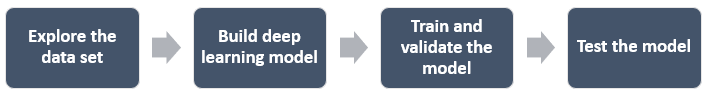

## Installing Packages

In [1]:
%pip install kagglehub numpy pandas matplotlib seaborn opencv-python-headless tensorflow keras scikit-learn pillow tqdm

Note: you may need to restart the kernel to use updated packages.


## Importing Libraries

In [2]:
import kagglehub # KaggleHub for dataset download
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # Statistical data visualization
import cv2 #Image reading and processing
import tensorflow as tf # Deep learning framework
from PIL import Image # Image reading and processing
import os # Operating system interactions
from sklearn.model_selection import train_test_split # Predicting and model summary
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tqdm import tqdm # Progress bar for loops

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-19 19:59:55.915492: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:59:56.097939: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:59:56.215340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750363196.407864   46745 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750363196.473440   46745 cuda_blas.cc:1407] Una

In [3]:
# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


## Exploring Data

### Fetch the path for the images

Since the image path and the images are stored separately, fetch the path of the images from the folders where it is stored.

In [4]:
data = []
labels = []
classes = 43

dataset_dir = '/home/codespace/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1'
#Retrieving the images and their labels 
metaDf = pd.read_csv(f"{dataset_dir}/Meta.csv")
trainDf = pd.read_csv(f"{dataset_dir}/Train.csv")
testDf = pd.read_csv(f"{dataset_dir}/Test.csv")
labels = ['20 km/h', '30 km/h', '50 km/h', '60 km/h', '70 km/h', '80 km/h', '80 km/h end', '100 km/h', '120 km/h', 'No overtaking',
               'No overtaking for tracks', 'Crossroad with secondary way', 'Main road', 'Give way', 'Stop', 'Road up', 'Road up for track', 'Brock',
               'Other dangerous', 'Turn left', 'Turn right', 'Winding road', 'Hollow road', 'Slippery road', 'Narrowing road', 'Roadwork', 'Traffic light',
               'Pedestrian', 'Children', 'Bike', 'Snow', 'Deer', 'End of the limits', 'Only right', 'Only left', 'Only straight', 'Only straight and right', 
               'Only straight and left', 'Take right', 'Take left', 'Circle crossroad', 'End of overtaking limit', 'End of overtaking limit for track']
print('SHAPE of training set:',trainDf.shape)
print('SHAPE of test set:',trainDf.shape)
print('SHAPE of MetaInfo:',trainDf.shape)


SHAPE of training set: (39209, 8)
SHAPE of test set: (39209, 8)
SHAPE of MetaInfo: (39209, 8)


### Load the path 

In [5]:
trainDf['Path'] = list(map(lambda x: os.path.join(dataset_dir, x.lower()), trainDf['Path']))
testDf['Path'] = list(map(lambda x: os.path.join(dataset_dir, x.lower()), testDf['Path']))
metaDf['Path'] = list(map(lambda x: os.path.join(dataset_dir, x.lower()), metaDf['Path']))

## Print the samples from the files to verify its correctness

In [6]:
trainDf.sample(10)

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
16747,36,34,6,6,31,29,10,/home/codespace/.cache/kagglehub/datasets/meow...
6785,31,30,6,5,26,25,4,/home/codespace/.cache/kagglehub/datasets/meow...
28344,85,79,8,7,77,72,24,/home/codespace/.cache/kagglehub/datasets/meow...
35189,27,27,6,5,22,22,35,/home/codespace/.cache/kagglehub/datasets/meow...
26587,39,36,6,6,34,31,18,/home/codespace/.cache/kagglehub/datasets/meow...
7857,88,89,7,8,81,82,4,/home/codespace/.cache/kagglehub/datasets/meow...
32368,108,97,9,8,99,89,31,/home/codespace/.cache/kagglehub/datasets/meow...
23160,42,42,6,6,37,37,14,/home/codespace/.cache/kagglehub/datasets/meow...
27017,49,43,5,5,44,38,21,/home/codespace/.cache/kagglehub/datasets/meow...
38762,27,29,5,6,22,24,41,/home/codespace/.cache/kagglehub/datasets/meow...


In [7]:
metaDf.sample(10)

,Path,ClassId,ShapeId,ColorId,SignId
5,/home/codespace/.cache/kagglehub/datasets/meow...,12,2,2,2.3
22,/home/codespace/.cache/kagglehub/datasets/meow...,29,0,0,1.34
41,/home/codespace/.cache/kagglehub/datasets/meow...,8,1,0,3.29
34,/home/codespace/.cache/kagglehub/datasets/meow...,4,1,0,3.29
9,/home/codespace/.cache/kagglehub/datasets/meow...,16,1,0,3.3
8,/home/codespace/.cache/kagglehub/datasets/meow...,15,1,0,3.1
40,/home/codespace/.cache/kagglehub/datasets/meow...,7,1,0,3.29
16,/home/codespace/.cache/kagglehub/datasets/meow...,22,0,0,1.1
4,/home/codespace/.cache/kagglehub/datasets/meow...,11,0,0,1.22
27,/home/codespace/.cache/kagglehub/datasets/meow...,33,1,1,4.2


### Analyze the class distribution using Histogram

The data set may be imbalanced meaning that, the number of samples available for each class may not same. So, it is advisable to analyze the class distribution so that training and validation of the model can be implemented accordingly.

To find the data set imbalance, Histogram plot is used. From the below output, we can see that, this class distribution for this data set is not uniform. Seaborn library is used to plot and visualize the histogram. Also, we can observer that, the subset of train and test dataset almost have similar class imbalance.

/tmp/ipykernel_46745/4070678106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ClassId", data=trainDf, ax=axs[0], palette="Set1", legend=False)
/tmp/ipykernel_46745/4070678106.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ClassId", data=testDf, ax=axs[1], palette="Set1", legend=False)


Text(0.5, 0, 'Class ID')

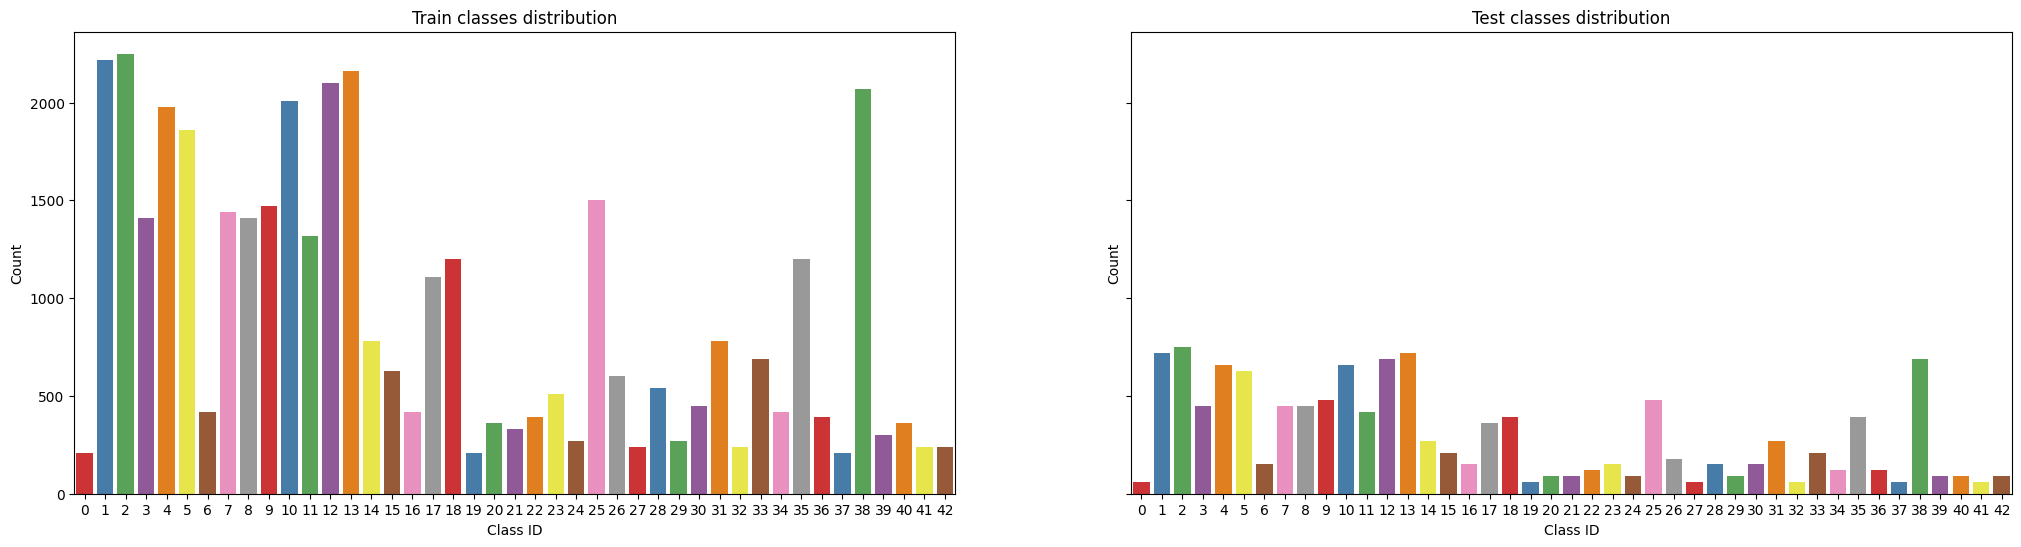

In [8]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(25, 6))
axs[0].set_title('Train classes distribution')
axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[1].set_title('Test classes distribution')
axs[1].set_xlabel('Class')
axs[1].set_ylabel('Count')

sns.countplot(x="ClassId", data=trainDf, ax=axs[0], palette="Set1", legend=False)
sns.countplot(x="ClassId", data=testDf, ax=axs[1], palette="Set1", legend=False)
axs[0].set_xlabel('Class ID')
axs[1].set_xlabel('Class ID')

### Analyze the size distribution of images

Since the accuracy of the sign recognition is dependent of the quality of the images, it is requiring knowing the resolution of the images.

KDE Plot also called as Kernel Density Estimate is used for visualizing the PDF- Probability Density function of a continuous variable. Seaborn is used to plot KDE plot.  The below plot shoes the probability density at different values in a continuous variable.

A multivariate plotting is used to visualize width and height of the images. This dataset contains thousands of images but not with same resolution. we can see from below given output that, most of images is rectangular, most of them are about 35x35 pixels resolution and few samples have high resolution like a 100x100 pixels.

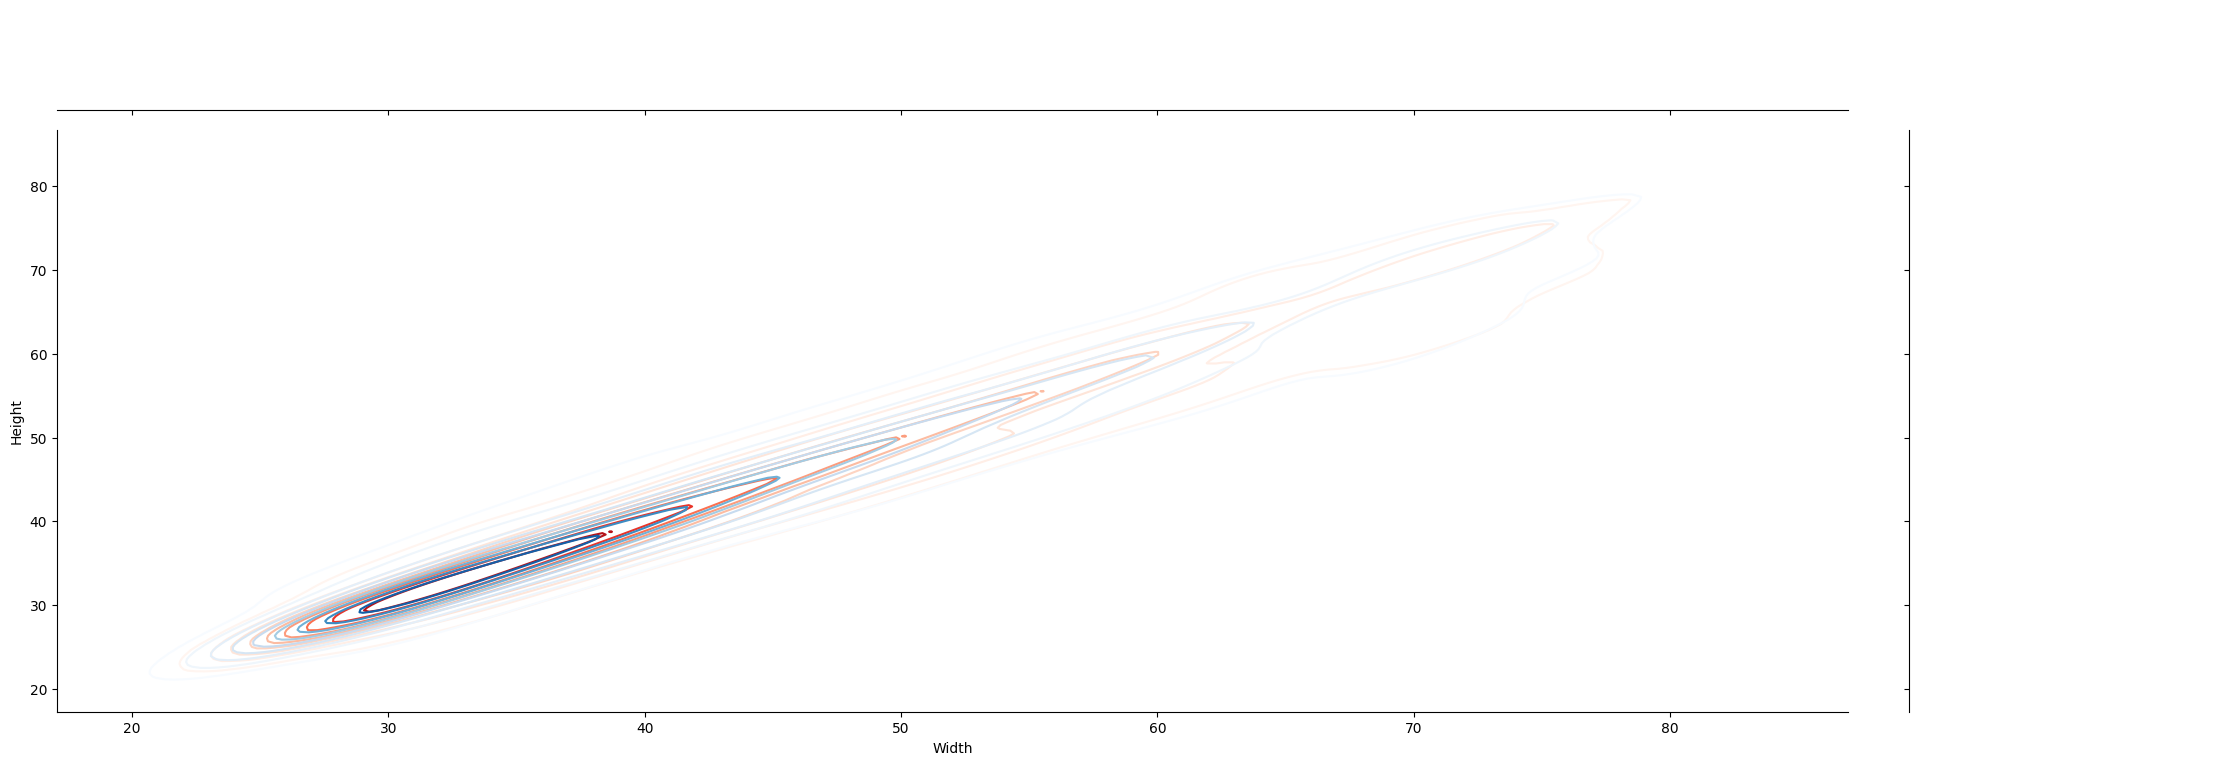

In [9]:
trainDfDpiSubset = trainDf[(trainDf.Width < 80) & (trainDf.Height < 80)]
testDfDpiSubset = testDf[(testDf.Width < 80) & (testDf.Height < 80)]
g = sns.JointGrid(x="Width", y="Height", data=trainDfDpiSubset)
sns.kdeplot(x="Width", y="Height", data=trainDfDpiSubset, cmap="Reds", fill=False, ax=g.ax_joint)
sns.kdeplot(x="Width", y="Height", data=testDfDpiSubset, cmap="Blues", fill=False, ax=g.ax_joint)
g.fig.set_figwidth(25)
g.fig.set_figheight(8)
plt.show()

### Visualize the target class

The target class in this data set can be considered as a sample but as an image indicating the sign. Some of the images may be different from the dataset samples so, few target class samples are visualized.

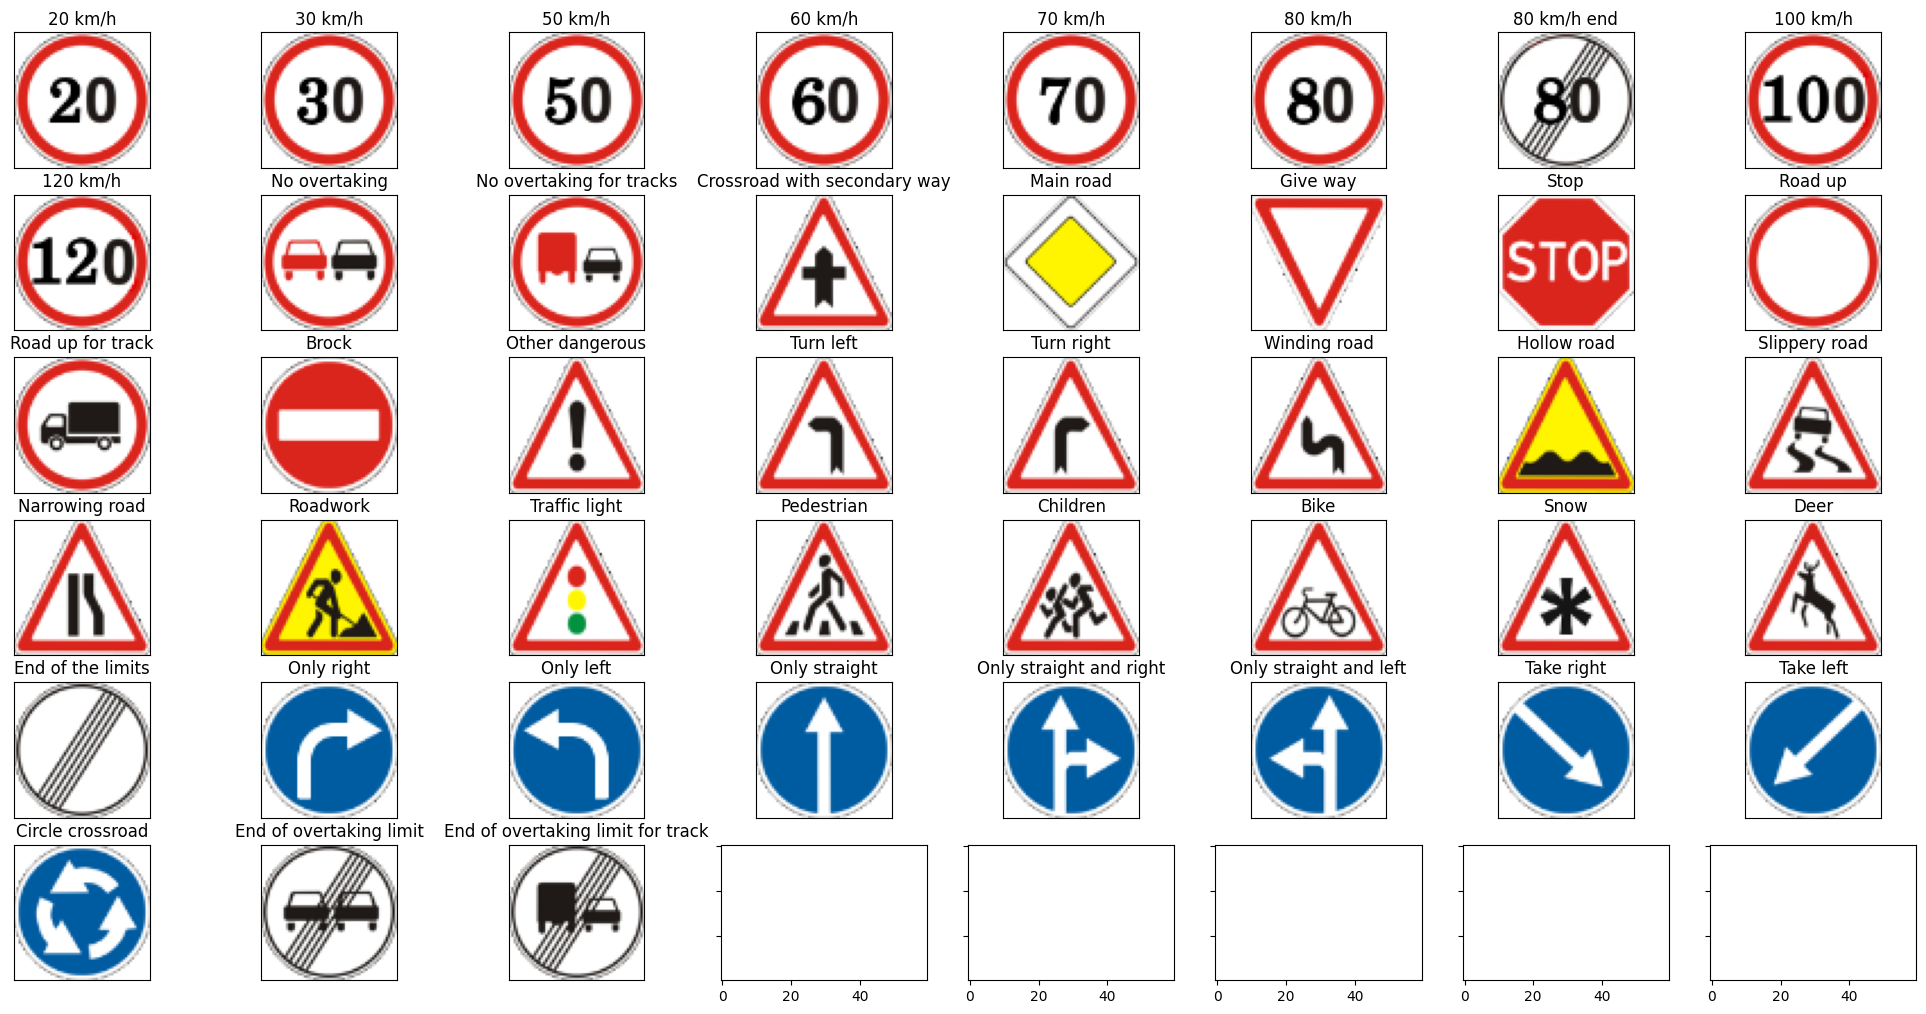

In [10]:
sns.set_style()
rows = 6
cols = 8
fig, axs = plt.subplots(rows, cols, sharex=True, sharey=True, figsize=(25, 12))
plt.subplots_adjust(left=None, bottom=None, right=None, top=0.9, wspace=None, hspace=None)
metaDf = metaDf.sort_values(by=['ClassId'])
idx = 0
for i in range(rows):
    for j in range(cols):
        if idx > 42:
            break
            
        img = cv2.imread(metaDf["Path"].tolist()[idx], cv2.IMREAD_UNCHANGED)
        img[np.where(img[:,:,3]==0)] = [255,255,255,255]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (60,60))
        
        axs[i,j].imshow(img)
        axs[i,j].set_facecolor('xkcd:salmon')
        axs[i,j].set_facecolor((1.0, 0.47, 0.42))
        axs[i,j].set_title(labels[int(metaDf["ClassId"].tolist()[idx])])
        axs[i,j].get_xaxis().set_visible(False)
        axs[i,j].get_yaxis().set_visible(False)
        idx += 1

### Visualize the Training set

Few images of the training set are also visualized

C:/Users/meenakshi.h/Documents/Traffic_sign_Recognition/


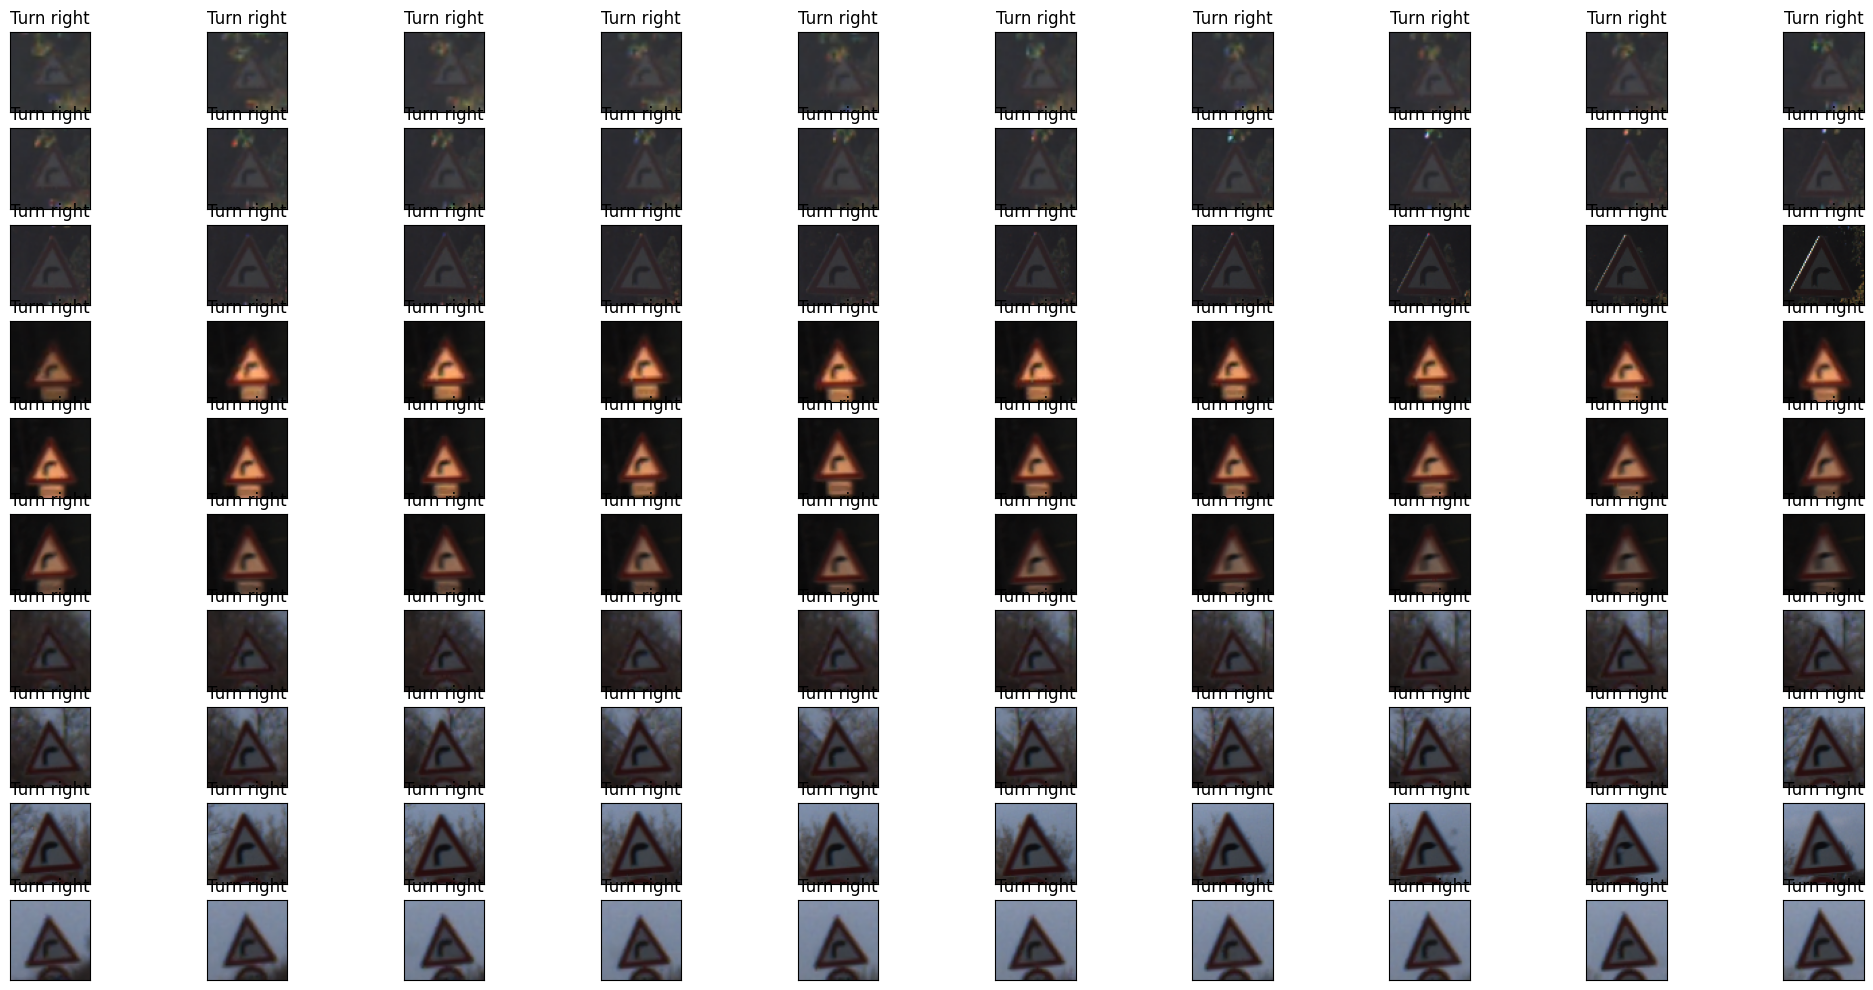

In [11]:
rows = 10
cols = 10
fig, axs = plt.subplots(rows, cols, sharex=True, sharey=True, figsize=(25, 12))
plt.subplots_adjust(left=None, bottom=None, right=None, top=0.9, wspace=None, hspace=None)
cur_path = 'C:/Users/meenakshi.h/Documents/Traffic_sign_Recognition/'
print(cur_path)
idx = 0
for i in range(rows):
    for j in range(cols):
        path = os.path.join(cur_path,trainDf["Path"].tolist()[idx]) 
        img = cv2.imread(path,cv2.IMREAD_UNCHANGED)
        #print(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (60,60))
        axs[i,j].imshow(img)
        axs[i,j].set_title(labels[int(trainDf["ClassId"].tolist()[idx])])
        axs[i,j].get_xaxis().set_visible(False)
        axs[i,j].get_yaxis().set_visible(False)
        idx += 1

## Model building using Convolutional Neural Network

### Extract the path for training, testing and label images

Image path and the images are stored separately, fetch the path of the images from the folders where it is stored.

In [12]:
data = []
labels_list = []

# Use the 'Path' and 'ClassId' columns from trainDf
for idx, row in tqdm(trainDf.iterrows(), total=len(trainDf)):
    try:
        image = Image.open(row['Path'])
        image = image.resize((30, 30))
        image = np.array(image)
        data.append(image)
        labels_list.append(row['ClassId'])
    except Exception as e:
        print(f"Error loading image {row['Path']}: {e}")

data = np.array(data)
labels_list = np.array(labels_list)
print("Loaded images:", data.shape)
print("Loaded labels:", labels_list.shape)

100%|██████████| 39209/39209 [00:18<00:00, 2160.33it/s]


Loaded images: (39209, 30, 30, 3)
Loaded labels: (39209,)


### Read the images and convert to numpy arrays

We need to convert the list into numpy arrays for feeding to the model.

In [14]:
#Converting lists into numpy arrays
data = np.array(data)
labels = np.array(labels)
print(data.shape, labels.shape)

(39209, 30, 30, 3) (43,)


### Split the training set

The training set is split as shown in the code. The shape of data is (31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)

which means that there are 31367 images of size 30×30 pixels and the 3 means that the data is represented in RGB color space. With the sklearn package, we use the train_test_split() method to split training and testing data.

In [16]:
#Splitting training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(data, labels_list, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


### Convert the label using one hot encoding

From the <keras.utils> package, <to_categorical> method is used to convert the labels present in y_train and t_test into one-hot encoding.

In [17]:
#Converting the labels into one hot encoding
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

### Building CNN Model

CNN model is used to Classify of the images into their corresponding categories.

The description of the CNN architecture used here is:

   - 2 Conv2D layer (filter=32, kernel_size=(5,5), activation=”relu”)
   - MaxPool2D layer ( pool_size=(2,2))
   - Dropout layer (rate=0.25)
   - 2 Conv2D layer (filter=64, kernel_size=(3,3), activation=”relu”)
   - MaxPool2D layer ( pool_size=(2,2))
   - Dropout layer (rate=0.25)
   - Flatten layer to squeeze the layers into 1 dimension
   - Dense Fully connected layer (256 nodes, activation=”relu”)
   - Dropout layer (rate=0.5)
   - Dense layer (43 nodes, activation=”softmax”)

In [18]:
#Building the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-19 20:11:22.318914: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Compile the model

The model needs to be compiled for the hyperparameters. We have used Adam optimizer to compile the model which performs gives better accuracy and converges fast. Since the classes are categorical, “categorical_crossentropy” is used as loss function with adam optimizer.

In [19]:
#Compilation of the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
epochs = 15
history = model.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/15


2025-06-19 20:11:47.686786: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 84690900 exceeds 10% of free system memory.


  2/981 ━━━━━━━━━━━━━━━━━━━━ 1:39 101ms/step - accuracy: 0.0078 - loss: 35.2568  

2025-06-19 20:11:50.384135: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 15676416 exceeds 10% of free system memory.
2025-06-19 20:11:50.385461: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 15676416 exceeds 10% of free system memory.
2025-06-19 20:11:50.399679: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29427200 exceeds 10% of free system memory.
2025-06-19 20:11:50.464350: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21496800 exceeds 10% of free system memory.


981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 72ms/step - accuracy: 0.3144 - loss: 3.1274 - val_accuracy: 0.8305 - val_loss: 0.6141
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.7597 - loss: 0.8033 - val_accuracy: 0.9517 - val_loss: 0.1822
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 87s 78ms/step - accuracy: 0.8650 - loss: 0.4617 - val_accuracy: 0.9565 - val_loss: 0.1626
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 75s 71ms/step - accuracy: 0.8972 - loss: 0.3522 - val_accuracy: 0.9515 - val_loss: 0.1659
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9145 - loss: 0.2899 - val_accuracy: 0.9705 - val_loss: 0.1043
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.9205 - loss: 0.2845 - val_accuracy: 0.9744 - val_loss: 0.0964
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.9281 - loss: 0.2520 - val_accuracy: 0.9807 - val_loss: 0.0682
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 114ms/step - accuracy: 0.9362 - loss: 0.2287 - val_accur

### Plot the accuracy and loss

Graphs are plotted to visualize the epoch vs accuracy and epoch vs Loss function

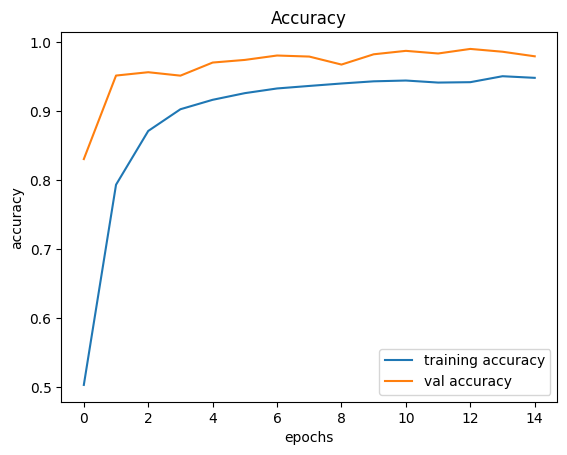

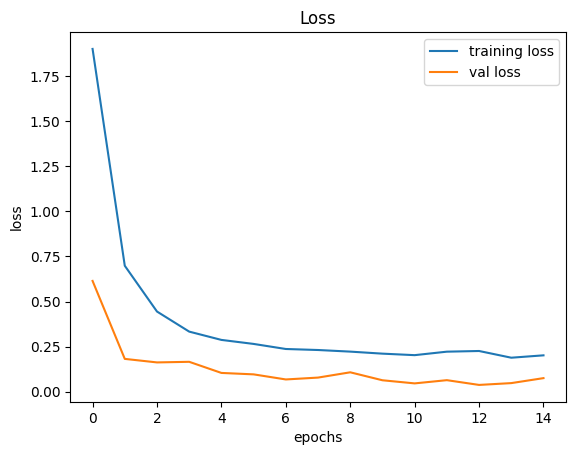

In [20]:
#plotting graph for accuracy
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
# plotting graph for loss
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

### Load the test data along with labels

This dataset contains a Test folder: details related to the image path and in a Test.csv file their respective class labels. We first extract the image path and labels using pandas. Images is resized to 30×30 pixels. We use numpy array to store all image data.

In [21]:
# Prepare test data and labels
X_test_data = []
y_test_labels = []

for idx, row in tqdm(testDf.iterrows(), total=len(testDf)):
    try:
        image = Image.open(row['Path'])
        image = image.resize((30, 30))
        image = np.array(image)
        X_test_data.append(image)
        y_test_labels.append(row['ClassId'])
    except Exception as e:
        print(f"Error loading image {row['Path']}: {e}")

X_test_data = np.array(X_test_data)
y_test_labels = np.array(y_test_labels)

print("Test images shape:", X_test_data.shape)
print("Test labels shape:", y_test_labels.shape)

100%|██████████| 12630/12630 [00:06<00:00, 2075.35it/s]

Test images shape: (12630, 30, 30, 3)
Test labels shape: (12630,)


### Predict the class

Using the test images the class label is predicted. We import <accuracy_score> from the <sklearn.metrics>, and observe the predicted value.

In [23]:
X_test = np.array(data)
pred_probs = model.predict(X_test)
pred = np.argmax(pred_probs, axis=1)
from sklearn.metrics import accuracy_score
print(accuracy_score(labels_list, pred))

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step
0.9837282256624754
